#  Healthcare Data Analysis

##  Problem Statement

Healthcare organizations generate large volumes of patient data, including demographics, medical conditions, hospital admissions, treatment costs, and insurance information. Analyzing this data can help hospitals understand patient patterns, manage healthcare resources more effectively, and improve operational efficiency.

The goal of this project is to perform **Exploratory Data Analysis (EDA)** on healthcare data to uncover trends in patient demographics, hospital admissions, medical conditions, length of stay, and billing patterns.

##  Project Objectives

- Analyze the **distribution of patients by age and gender**
- Identify trends in **hospital admission types**
- Understand how **medical conditions affect length of hospital stay**
- Examine **billing patterns across doctors, hospitals, and insurance providers**
- Generate insights for **healthcare planning and decision making**

##  Dataset Description

The dataset contains healthcare-related information about patients admitted to hospitals. It includes demographic details, admission information, medical conditions, billing data, and insurance providers.

## Import Libraries

The following Python libraries are used for data analysis and visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

The dataset is loaded using Pandas to begin the data analysis process.

In [2]:
#read_excel functions helps to load the excel file data and create a dataframe in pandas
df = pd.read_excel("../data/healthcare_dataset.xlsx")

## Data Exploration

Initial exploration is performed to understand the dataset structure, including the number of rows, columns, data types, and missing values.

In [3]:
#shows data for first 10 rows
df.head(10)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,EMILY JOHNSOn,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,edwArD EDWaRDs,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,CHrisTInA MARtinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,JASmINe aGuIlaR,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,ChRISTopher BerG,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [4]:
#gives us the total no of rows and columns
df.shape

(55500, 15)

There are 55500 rows and 15 columns in the dataset.

In [5]:
#it gives the structure, data type, non null values and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                55500 non-null  object        
 1   Age                 55500 non-null  int64         
 2   Gender              55500 non-null  object        
 3   Blood Type          55500 non-null  object        
 4   Medical Condition   55500 non-null  object        
 5   Date of Admission   55500 non-null  datetime64[ns]
 6   Doctor              55500 non-null  object        
 7   Hospital            55500 non-null  object        
 8   Insurance Provider  55500 non-null  object        
 9   Billing Amount      55500 non-null  float64       
 10  Room Number         55500 non-null  int64         
 11  Admission Type      55500 non-null  object        
 12  Discharge Date      55500 non-null  datetime64[ns]
 13  Medication          55500 non-null  object    

In [6]:
#it describes the statsical summary of the dataset(numeric column)
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,55500.000000,55500,55500.000000,55500.000000,55500
mean,51.539459,2021-11-01 01:02:22.443243008,25539.316097,301.134829,2021-11-16 13:15:20.821621504
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.602454,NaN,14211.454431,115.243069,NaN


We can understand the range of patients age is 13 to 89. The minimum billing amount is negative.

## Data Cleaning & Preparation

In this section, the dataset is cleaned and prepared for analysis. This includes:  
1 Checking missing values  
2 Handling duplicates  
3 Verifying data types  
4 Creating derived features if required  

In [7]:
df[df['Billing Amount']<0].shape

(108, 15)

this shows 108 rows has negative values

##  Removing Invalid Billing Records

Records with negative billing amounts were removed from the dataset. This step ensures that the analysis only includes valid financial data.

In [8]:
df = df[df['Billing Amount']>0]

Cleaning invalid billing values improves the overall data quality and prevents misleading insights during exploratory data analysis and visualization.

In [9]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date
count,55392.000000,55392,55392.000000,55392.000000,55392
mean,51.538543,2021-11-01 03:08:47.209705472,25590.084632,301.119205,2021-11-16 15:21:25.268630528
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13297.478682,202.000000,2020-08-12 00:00:00
50%,52.000000,2021-11-01 00:00:00,25573.823359,302.000000,2021-11-17 00:00:00
75%,68.000000,2023-02-03 00:00:00,37849.210062,401.000000,2023-02-18 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.602045,NaN,14178.657522,115.238552,NaN


In [10]:
#it summarizes the categorical data
df.describe(include = 'object')

,Name,Gender,Blood Type,Medical Condition,Doctor,Hospital,Insurance Provider,Admission Type,Medication,Test Results
count,55392,55392,55392,55392,55392,55392,55392,55392,55392,55392
unique,49896,2,8,6,40276,39815,5,3,5,3
top,DAvId muNoZ,Male,A-,Arthritis,Michael Smith,LLC Smith,Cigna,Elective,Lipitor,Abnormal
freq,3,27726,6953,9297,27,44,11225,18618,11119,18589


##  Checking for Null Records

In [11]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

We can see that there is no null value present in the dataset

##  Checking for Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(532)

The analysis revealed that **532 duplicate records** were present in the dataset. Duplicate records can distort analysis results by counting the same observation multiple times. Therefore, these duplicates need to be removed to maintain the accuracy and reliability of the dataset before performing further analysis.

In [13]:
#remove duplicates
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

## Convert name in proper format

In [15]:
df['Name']= df['Name'].str.strip().str.title()

In [16]:
df.head(10)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
5,Emily Johnson,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,389,Urgent,2023-12-24,Ibuprofen,Normal
6,Edward Edwards,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,389,Emergency,2020-11-15,Paracetamol,Inconclusive
7,Christina Martinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,"Powell Robinson and Valdez,",Cigna,45820.462722,277,Emergency,2022-01-07,Paracetamol,Inconclusive
8,Jasmine Aguilar,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,316,Elective,2020-07-14,Aspirin,Abnormal
9,Christopher Berg,58,Female,AB-,Cancer,2021-05-23,Heather Day,Padilla-Walker,UnitedHealthcare,19784.631062,249,Elective,2021-06-22,Paracetamol,Inconclusive


In [17]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [18]:
#check the data type 
df[['Date of Admission', 'Discharge Date']].dtypes

Date of Admission    datetime64[ns]
Discharge Date       datetime64[ns]
dtype: object

##  Length of Stay

A new column **Length of Stay** was created by calculating the difference between **Discharge Date** and **Admission Date** to determine the number of days a patient stayed in the hospital.

In [19]:
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

This metric helps analyze hospitalization duration and understand patient stay patterns in hospitals

In [20]:
df[['Date of Admission', 'Discharge Date', 'Length of Stay']].head()

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


In [21]:
#looking for negative value
df[df['Length of Stay']<0]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


It return only header means there is no negative value present in Length of Stay

In [22]:
df['Length of Stay'].min()

1

Minimum length of stay is one day

##  Same-Day Discharge Check

The dataset was checked for cases where **Length of Stay = 0**, which would indicate patients admitted and discharged on the same day.

In [23]:
df[df['Length of Stay']==0]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay


The analysis shows **no records with Length of Stay equal to 0**, indicating that all patients in the dataset stayed in the hospital for **at least one day**.

## Looking for missing value

In [24]:
df['Length of Stay'].isna().sum()

np.int64(0)

##  Length of Stay Category
A new feature **Stay Category** was created by grouping the **Length of Stay** into categories such as **Short Stay, Medium Stay, and Long Stay**.
Categorizing hospital stay duration helps simplify the analysis and makes it easier to identify patterns in patient hospitalization periods.

In [25]:
df['Stay Category'] = pd.cut(
    df['Length of Stay'],
    bins = [0,3,7,14, df['Length of Stay'].max()],
    labels = ['Short Stay', 'Medium Stay', 'Long Stay', 'Extended Stay']
)

In [26]:
#verify result
df[['Length of Stay', 'Stay Category']].head()

,Length of Stay,Stay Category
0,2,Short Stay
1,6,Medium Stay
2,15,Extended Stay
3,30,Extended Stay
4,20,Extended Stay


## Stay Category Distribution

In [27]:
df['Stay Category'].value_counts()

Stay Category
Extended Stay    29145
Long Stay        12853
Medium Stay       7407
Short Stay        5455
Name: count, dtype: int64

- **Extended Stay** has the highest number of patients (29,145), indicating many cases require longer hospitalization.
- **Long Stay** is the second most common category (12,853 patients).
- **Medium Stay** (7,407) and **Short Stay** (5,455) represent fewer patient admissions.
- The distribution suggests that a significant portion of patients require **long-term hospital care**, which may impact hospital resource planning and bed management.

In [28]:
df= df.drop(columns = ['Room Number'])

The **Room Number** column was removed from the dataset as it does not contribute meaningful information for the analysis.

In [29]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Admission Type', 'Discharge Date', 'Medication',
       'Test Results', 'Length of Stay', 'Stay Category'],
      dtype='object')

In [30]:
#check if anyone has an age less than or equal to 12
df[df['Age'] <=12 ]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length of Stay,Stay Category


## Age Category
A new column **Age Category** was created by grouping patients into different age groups to simplify demographic analysis.

In [31]:
df['Age Category'] = pd.cut(
    df['Age'],
    bins = [12,19,35,60, df['Age'].max()],
    labels = ['Teen', 'Young Adult', 'Adult', 'Senior']
)

In [32]:
df[['Age', 'Age Category']].head()

,Age,Age Category
0,30,Young Adult
1,62,Senior
2,76,Senior
3,28,Young Adult
4,43,Adult


In [33]:
df['Age Category'].value_counts()

Age Category
Adult          20349
Senior         20135
Young Adult    12702
Teen            1674
Name: count, dtype: int64

- **Adults (20,349)** represent the largest group of patients in the dataset.
- **Seniors (20,135)** also make up a significant portion of hospital admissions.
- **Young Adults (12,702)** account for a moderate number of cases.
- **Teen patients (1,674)** represent the smallest group.

## Data Visualizations

Various visualizations are created to better understand customer purchasing behavior.

In [34]:
plt.figure(figsize=(8,5))
sns.set_style("whitegrid")


<Figure size 800x500 with 0 Axes>

## Patient Distribution by Age Category

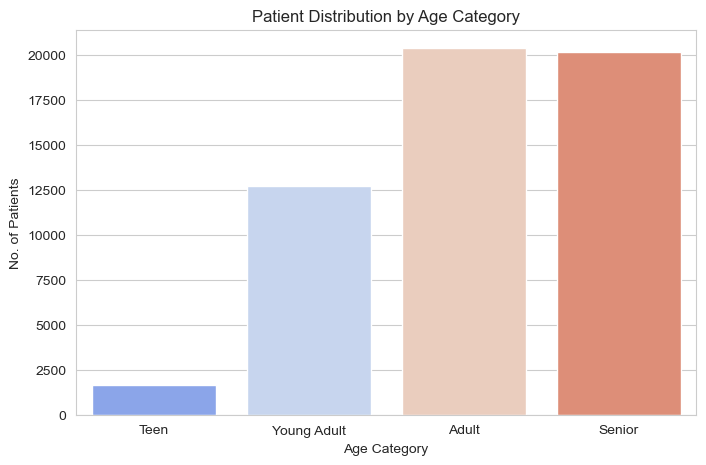

In [35]:
plt.figure(figsize=(8,5))
sns.countplot(data= df, x='Age Category', hue = 'Age Category', palette = 'coolwarm')
plt.title("Patient Distribution by Age Category")
plt.xlabel("Age Category")
plt.ylabel("No. of Patients")
plt.show()

- Adult and Senior patients make up the majority of hospital admissions.
- Young Adults represent a moderate portion of patients.
- Teen patients account for the smallest share of hospital visits.
- The distribution indicates that healthcare demand is higher among **adult and older populations**.

## Gender Distribution

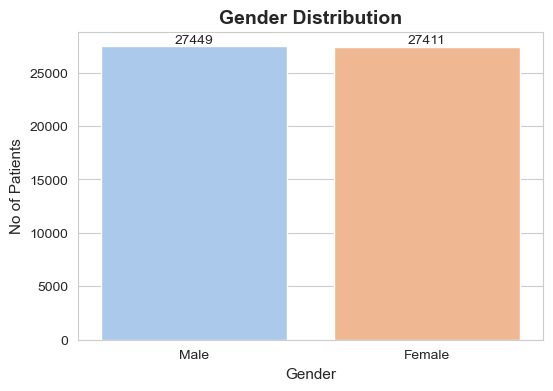

In [36]:
plt.figure(figsize = (6,4))
ax = sns.countplot(data = df, x = 'Gender', hue = 'Gender', legend = False, palette = 'pastel')
for container in ax.containers:
    ax.bar_label(container)
plt.title("Gender Distribution", fontweight = 'bold', fontsize = 14)
plt.xlabel("Gender", fontsize = 11)
plt.ylabel("No of Patients", fontsize = 11)
plt.show()

 The number of male and female patients appears relatively balanced.

## Admission type Distribution

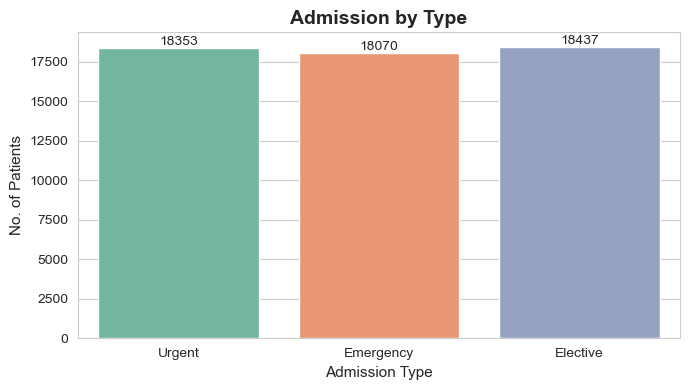

In [37]:
plt.figure(figsize = (7,4))
ax = sns.countplot(data =df, x = 'Admission Type', hue = 'Admission Type', legend = False, palette = 'Set2')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Admission by Type", fontsize = 14, fontweight = 'bold')
plt.xlabel('Admission Type', fontsize =11)
plt.ylabel('No. of Patients', fontsize = 11)
plt.tight_layout()
plt.show()



Elective admission types occur significantly more frequently, followed by Urgent and Emergency.

## Admission type vs length of stay

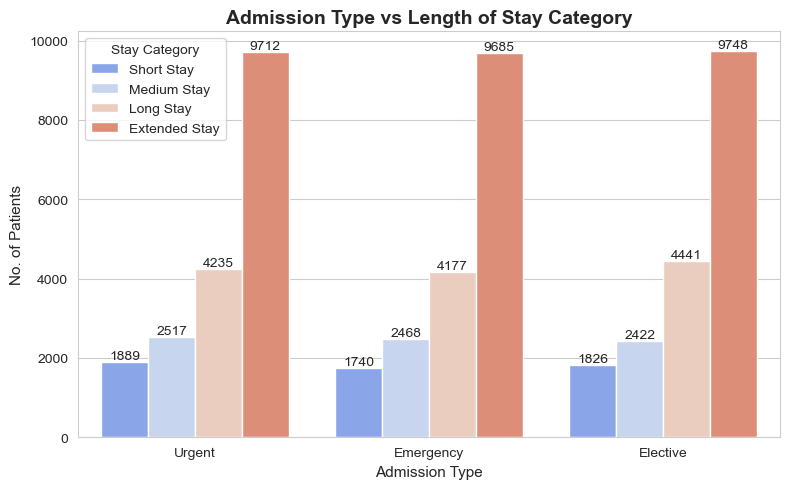

In [38]:
plt.figure(figsize = (8,5))
ax = sns.countplot(data= df, x = 'Admission Type', hue = 'Stay Category', palette = 'coolwarm')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Admission Type vs Length of Stay Category", fontsize = 14, fontweight = 'bold')
plt.xlabel("Admission Type", fontsize =11)
plt.ylabel("No. of Patients", fontsize = 11)

plt.legend(title ='Stay Category')
plt.tight_layout()
plt.show()

- Urgent admissions are more likely to result in Extended hospital stays.
- Elective or Emergency admissions tend to have shorter or more predictable stay durations.

## length of stay by medical condition

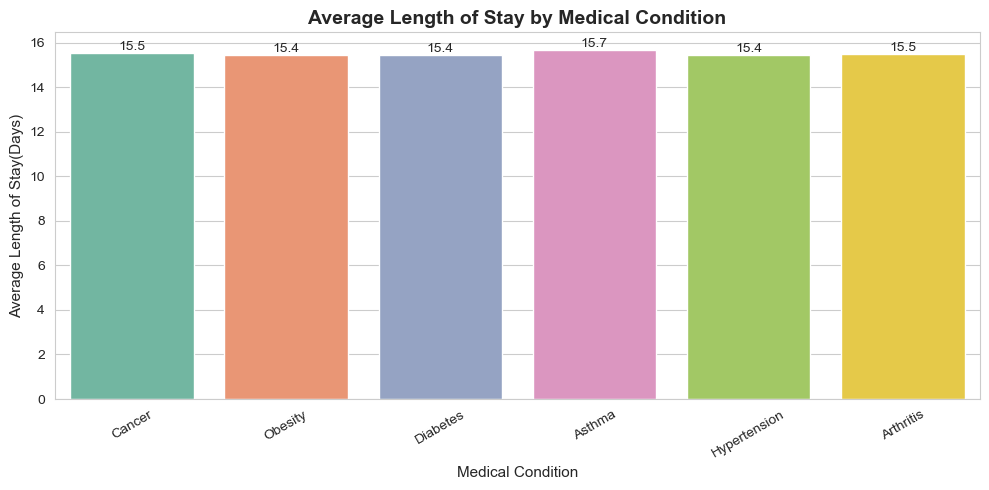

In [39]:
plt.figure(figsize = (10,5))
ax = sns.barplot(data = df, x= 'Medical Condition', y = 'Length of Stay', hue = 'Medical Condition',
                 palette = 'Set2', estimator = 'mean', legend = False, errorbar = None)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title("Average Length of Stay by Medical Condition", fontsize = 14, fontweight = 'bold')
plt.xlabel("Medical Condition", fontsize = 11)
plt.ylabel("Average Length of Stay(Days)", fontsize = 11)
plt.xticks(rotation = 30)

plt.tight_layout()
plt.show()


Patients across all six conditions stay remarkably consistent at ~15.4–15.7 days. Asthma shows the longest average (15.7), but overall variation is minimal, signaling standardized inpatient durations.

## boxplot for analyze outliers

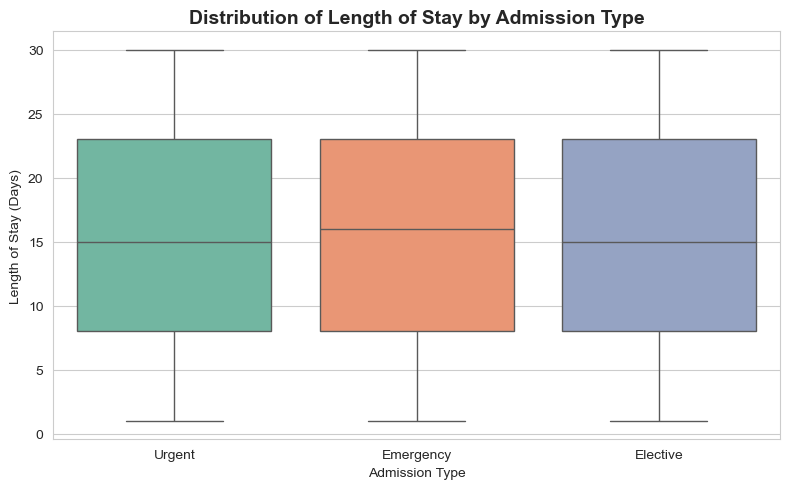

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Admission Type',
    y='Length of Stay',
    hue = 'Admission Type',
    legend = False,
    palette='Set2'
)

plt.title('Distribution of Length of Stay by Admission Type', fontsize=14, fontweight='bold')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (Days)')

plt.tight_layout()
plt.show()

- Boxplots reveal outliers in length of stay depending on admission type (e.g., emergency vs. elective).
- Emergency admissions show wider variability, indicating unpredictable resource needs.

## Billing Amount by top 10 doctors

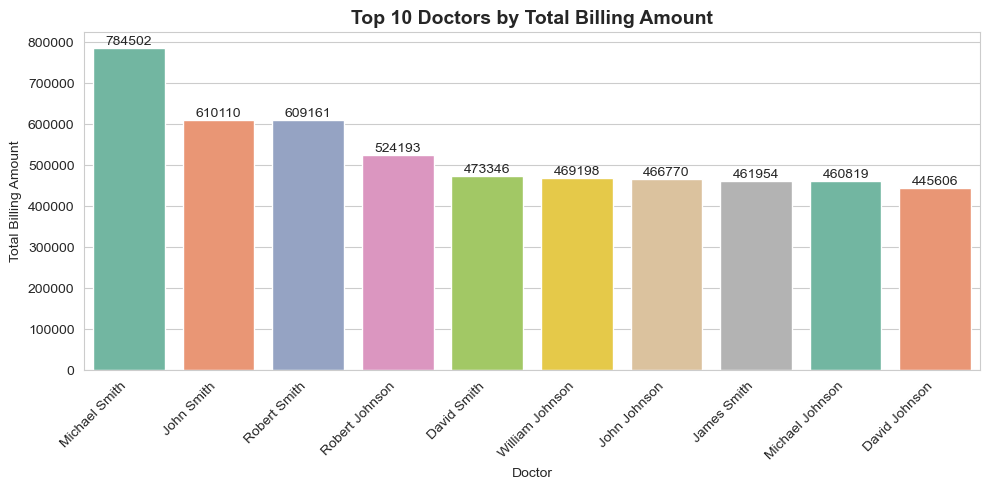

In [41]:
top_10_doctors = (
    df.groupby('Doctor')['Billing Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top_10_doctors,
    x='Doctor',
    y='Billing Amount',
    hue='Doctor',
    palette='Set2',
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Top 10 Doctors by Total Billing Amount', fontsize=14, fontweight='bold')
plt.xlabel('Doctor')
plt.ylabel('Total Billing Amount')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

- Ranking of top 10 doctors by billing amounts provides visibility into revenue concentration.
- Potential to identify high-value practitioners and monitor billing fairness

## Top 10 hosiptal by billing amount

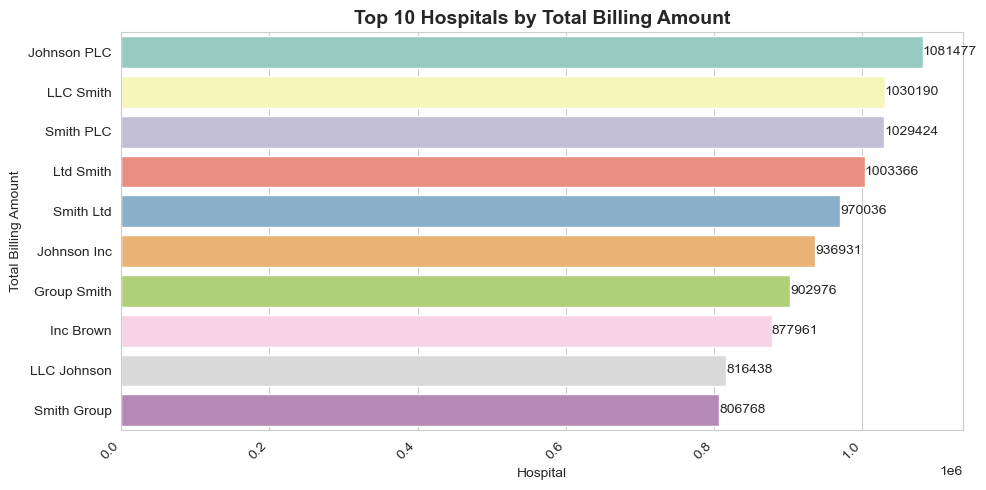

In [42]:
top_10_hospitals = (
    df.groupby('Hospital')['Billing Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=top_10_hospitals,
    y='Hospital',
    x='Billing Amount',
    hue='Hospital',
    palette='Set3',
    legend=False
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Top 10 Hospitals by Total Billing Amount', fontsize=14, fontweight='bold')
plt.xlabel('Hospital')
plt.ylabel('Total Billing Amount')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Johnson PLC leads with the highest billing amount (≈1.08M), standing out as the top revenue generator.

## Average Billing Amount by Medical Condition and Gender

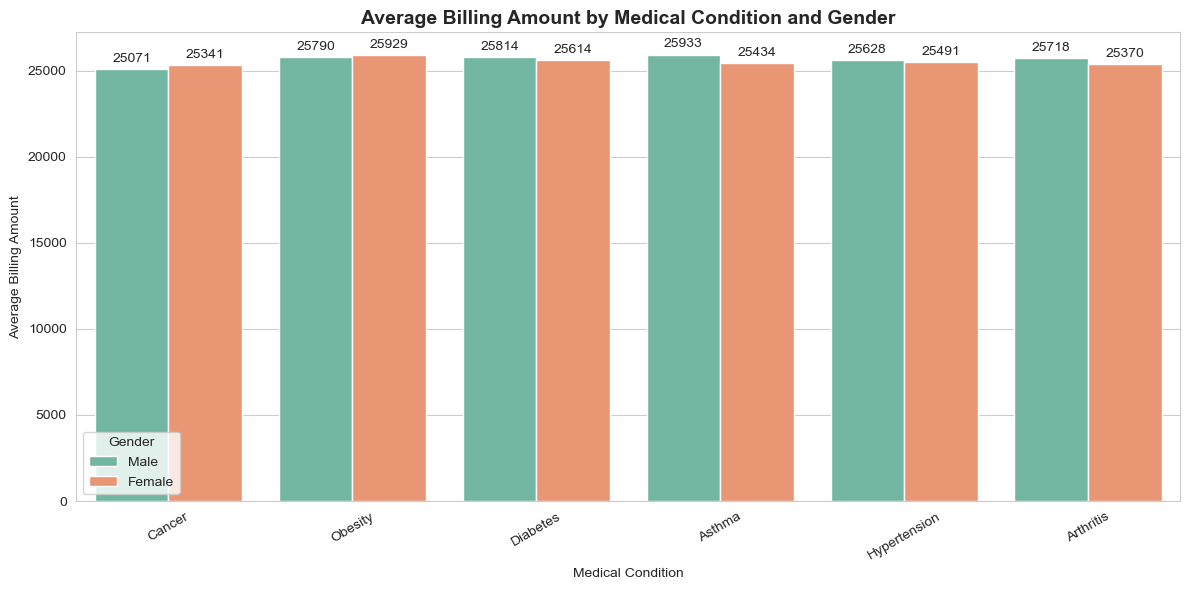

In [43]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount',
    hue='Gender',
    estimator='mean',
    palette='Set2',
    errorbar=None
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('Average Billing Amount by Medical Condition and Gender',
          fontsize=14, fontweight='bold')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=30)
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

Billing amounts are highly consistent across conditions, clustering around 25K–26K. Minor gender gaps appear, with males higher in asthma/diabetes and females slightly higher in cancer/obesity.

## Average Billing Amount by Insurance Provider

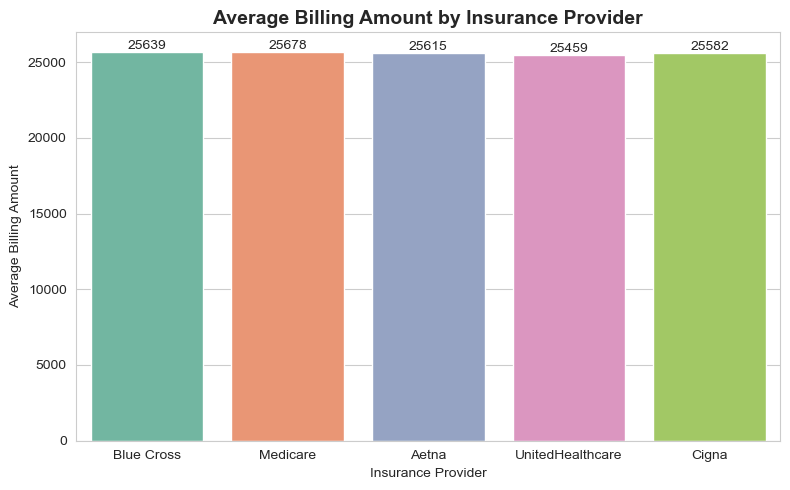

In [44]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df,
    x='Insurance Provider',
    y='Billing Amount',
    estimator='mean',
    hue = 'Insurance Provider',
    legend = False,
    palette='Set2',
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title('Average Billing Amount by Insurance Provider',
          fontsize=14, fontweight='bold')
plt.xlabel('Insurance Provider')
plt.ylabel('Average Billing Amount')

plt.tight_layout()
plt.show()

Billing averages are tightly clustered around 25.5K across all providers, showing strong consistency. Medicare edges slightly higher, while UnitedHealthcare is lowest, but the gap is negligible (<250).

##  Converting Column Names to Lowercase

All column names were converted to **lowercase** to maintain consistency and make them easier to work with during analysis.

In [45]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)

In [46]:
#convert it into csv
df.to_csv('healthcare.csv', index = False)

In [47]:
#check if it is converted 
df_check = pd.read_csv("healthcare.csv")
df_check.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,admission_type,discharge_date,medication,test_results,length_of_stay,stay_category,age_category
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal,2,Short Stay,Young Adult
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,Medium Stay,Senior
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal,15,Extended Stay,Senior
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal,30,Extended Stay,Young Adult
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal,20,Extended Stay,Adult


## SQL Connection

In [48]:
pip install pymysql sqlalchemy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [49]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# MySQL connection
username = "root"
password = quote_plus("sim@rsql2506")
host = "localhost"
port = "3306"
database = "healthcare_sys"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

# Write DataFrame to MySQL
table_name = "healthcare"   # choose any table name
df.to_sql(table_name, engine, if_exists="replace", index=False)

54860